In [1]:
!pip install -r requirements.txt

In [2]:
import kagglehub
# path = kagglehub.dataset_download("jessicali9530/lfw-dataset")
path = kagglehub.dataset_download("jangedoo/utkface-new")

/home/e20240011884/Documents/M2/Image, sécurité et deep learning/face_filters/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
import cv2
import os

In [4]:
# Load face detection classifier
face_classifier = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)

In [5]:
image_size = 128
images = []
ages = []

In [6]:
def preprocess_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        print(f"Warning: Could not load image {img_path}. Skipping.")
        return []

    grey_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_classifier.detectMultiScale(
        grey_img, scaleFactor=1.1, minNeighbors=5, minSize=(120, 120)
    )

    crops = []
    for (x, y, w, h) in faces:
        x_max = min(img.shape[1], x + w)
        y_max = min(img.shape[0], y + h)
        x = max(0, x)
        y = max(0, y)

        if w <= 0 or h <= 0:
            continue

        im_cropped = img[y:y_max, x:x_max]
        if im_cropped.size == 0:
            continue

        im_cropped = cv2.cvtColor(im_cropped, cv2.COLOR_BGR2RGB)
        im_cropped = cv2.resize(im_cropped, (image_size, image_size))
        im_cropped = im_cropped.astype("float32") / 255.0
        crops.append(im_cropped)

    return crops

In [7]:
import numpy as np

i = 0
numImg = 10000
for root, dirs, files in os.walk(path):
    for file in files:
        if i >= numImg:
            break
        if file.endswith(".jpg"):
            img_path = os.path.join(root, file)
            processed_crops = preprocess_image(img_path)
            age = int(file.split("_")[0])
            if len(processed_crops) == 0:
                continue
            for crop in processed_crops:
                images.append(crop)
                normalized_age = age / 116
                ages.append(normalized_age)
                i += 1
                if i >= numImg:
                    break


In [8]:
!pip show tensorflow

Name: tensorflow
Version: 2.20.0
Summary: TensorFlow is an open source machine learning framework for everyone.
Home-page: https://www.tensorflow.org/
Author: Google Inc.
Author-email: packages@tensorflow.org
License: Apache 2.0
Location: /home/e20240011884/Documents/M2/Image, sécurité et deep learning/face_filters/.venv/lib/python3.10/site-packages
Requires: absl-py, astunparse, flatbuffers, gast, google_pasta, grpcio, h5py, keras, libclang, ml_dtypes, numpy, opt_einsum, packaging, protobuf, requests, setuptools, six, tensorboard, termcolor, typing_extensions, wrapt
Required-by: 


In [9]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input

2025-12-01 17:14:57.916730: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-01 17:14:57.954941: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-01 17:15:06.765845: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [10]:
from sklearn.model_selection import train_test_split

x_train, x_test, x_train_ages, x_test_ages = train_test_split(
    images, ages, test_size=0.2, random_state=42
)

x_train = np.array(x_train, dtype=np.float32)
x_test = np.array(x_test, dtype=np.float32)

x_train_ages = np.array(x_train_ages, dtype=np.float32).reshape(-1,1)
x_test_ages = np.array(x_test_ages, dtype=np.float32).reshape(-1,1)

# Crear datasets de tf.data
batch_size = 32

train_dataset = tf.data.Dataset.from_tensor_slices((x_train, x_train_ages))
train_dataset = train_dataset.shuffle(buffer_size=1024).batch(batch_size)

val_dataset = tf.data.Dataset.from_tensor_slices((x_test, x_test_ages))
val_dataset = val_dataset.batch(batch_size)

print(x_train.shape, x_train_ages.shape)
print(x_test.shape, x_test_ages.shape)


I0000 00:00:1764605712.416073  207698 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 7102 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3080, pci bus id: 0000:01:00.0, compute capability: 8.6


(8000, 128, 128, 3) (8000, 1)
(2000, 128, 128, 3) (2000, 1)


In [11]:

from keras.saving import register_keras_serializable

def residual_block(x, filters, strides=1):
    shortcut = x
    if strides != 1 or x.shape[-1] != filters:
        shortcut = layers.Conv2D(filters, 1, strides=strides, padding="same")(shortcut)
    x = layers.Conv2D(filters, 3, strides=strides, padding="same", activation="relu")(x)
    x = layers.Conv2D(filters, 3, padding="same")(x)
    x = layers.Add()([x, shortcut])
    x = layers.Activation("relu")(x)
    return x

def build_encoder(latent_dim):
    encoder_inputs = Input(shape=(128,128,3))
    age_input = Input(shape=(1,))

    x = layers.Conv2D(16, 3, strides=2, padding="same", activation="relu")(encoder_inputs)
    x = residual_block(x, 32, strides=2)
    x = residual_block(x, 64, strides=2)
    x = residual_block(x, 128, strides=2)

    x_flat = layers.Flatten()(x)
    x_flat = layers.Dense(256, activation="relu")(x_flat)

    # Concatenar edad
    age_encoded = layers.Dense(32, activation="relu")(age_input)
    x_flat = layers.Concatenate()([x_flat, age_encoded])

    z_mean = layers.Dense(latent_dim)(x_flat)
    z_log_var = layers.Dense(latent_dim)(x_flat)

    @register_keras_serializable()
    def sampling(args):
        mean, log_var = args
        epsilon = tf.random.normal(shape=tf.shape(mean))
        return mean + tf.exp(0.5 * log_var) * epsilon

    z = layers.Lambda(sampling)([z_mean, z_log_var])

    return Model([encoder_inputs, age_input], [z_mean, z_log_var, z], name="encoder")



In [12]:
def build_decoder(latent_dim):
    z_inputs = Input(shape=(latent_dim,))
    age_input = Input(shape=(1,))

    # Procesar edad
    age_encoded = layers.Dense(32, activation="relu")(age_input)
    age_encoded = layers.Reshape((1,1,32))(age_encoded)
    age_encoded = layers.Lambda(lambda t: tf.tile(t, [1, 8, 8, 1]))(age_encoded)

    # Reconstrucción desde el latente
    x = layers.Dense(8*8*128, activation="relu")(z_inputs)
    x = layers.Reshape((8,8,128))(x)

    # Concatenar información de edad
    x = layers.Concatenate()([x, age_encoded])

    # Upsampling progresivo sin skips
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D()(x)

    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D()(x)

    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D()(x)

    x = layers.Conv2D(16, 3, padding="same", activation="relu")(x)
    x = layers.UpSampling2D()(x)

    outputs = layers.Conv2D(3, 3, activation="sigmoid", padding="same")(x)

    # Predicción de edad
    flat = layers.Flatten()(x)
    age_pred = layers.Dense(1, activation="linear", name="age_pred")(flat)

    return Model([z_inputs, age_input], [outputs, age_pred], name="decoder")



In [13]:
def build_discriminator():
    """Lighter discriminator with dropout"""
    model = keras.Sequential([
        layers.InputLayer(input_shape=(128, 128, 3)),
        
        # Block 1
        layers.Conv2D(64, (4, 4), strides=2, padding='same'),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # Block 2
        layers.Conv2D(128, (4, 4), strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # Block 3
        layers.Conv2D(256, (4, 4), strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # Block 4
        layers.Conv2D(512, (4, 4), strides=2, padding='same'),
        layers.BatchNormalization(),
        layers.LeakyReLU(0.2),
        layers.Dropout(0.3),
        
        # Output
        layers.Flatten(),
        layers.Dense(1)  # No sigmoid, use from_logits=True
    ])
    return model

In [28]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input

from keras_facenet import FaceNet
identity_model = FaceNet().model
identity_model.trainable = False

recon_weight = 1.0
kl_weight = 0.001
p_weight = 0.000002
identity_weight = 0.1
age_weight = 2
  
# --- Preparar modelo VGG para perceptual loss ---
vgg = VGG16(include_top=False, weights='imagenet', input_shape=(128,128,3))
vgg.trainable = False
layer_names = ['block3_conv3', 'block4_conv3']
vgg_outputs = [vgg.get_layer(name).output for name in layer_names]
vgg_model = Model(inputs=vgg.input, outputs=vgg_outputs)

def perceptual_loss(x_true, x_pred):
    # VGG espera imágenes en [0,255], actualmente tus imágenes están en [0,1]
    x_true_pp = preprocess_input(x_true * 255.0)
    x_pred_pp = preprocess_input(x_pred * 255.0)
    
    features_true = vgg_model(x_true_pp)
    features_pred = vgg_model(x_pred_pp)
    
    loss = 0
    for f_true, f_pred in zip(features_true, features_pred):
        loss += tf.reduce_mean(tf.square(f_true - f_pred))
    return loss

def identity_loss(x_true, x_pred):
    # FaceNet espera imágenes redimensionadas a 160x160 y con valores entre [0,255]
    x_true_resized = tf.image.resize(x_true, (160, 160)) * 255.0
    x_pred_resized = tf.image.resize(x_pred, (160, 160)) * 255.0

    # Obtener los embeddings de FaceNet
    emb_true = identity_model(x_true_resized)
    emb_pred = identity_model(x_pred_resized)

    # Asegurarse de que los embeddings estén normalizados
    emb_true = tf.nn.l2_normalize(emb_true, axis=-1)  # Normalización L2
    emb_pred = tf.nn.l2_normalize(emb_pred, axis=-1)  # Normalización L2

    # Usar distancia euclidiana entre los embeddings (pérdida de identidad)
    return tf.reduce_mean(tf.square(emb_true - emb_pred))

def age_loss(y_true_age, y_pred_age):
    return tf.reduce_mean(tf.square(y_true_age - y_pred_age))

bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)
def gan_loss(disc_real, disc_fake):
    real_loss = bce(tf.ones_like(disc_real), disc_real)
    fake_loss = bce(tf.zeros_like(disc_fake), disc_fake)
    return real_loss + fake_loss

In [29]:
class VAE(tf.keras.Model):
    def __init__(self, encoder, decoder, discriminator):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.discriminator = discriminator
        self.gan_weight = 0.0 

    def compile(self, gen_optimizer, disc_optimizer):
        super().compile()
        self.gen_optimizer = gen_optimizer
        self.disc_optimizer = disc_optimizer
        self.bce = tf.keras.losses.BinaryCrossentropy(from_logits=True)

    def train_step(self, data):
        x, age_input = data
        batch_size = tf.shape(x)[0]
        
        # ============================================================
        # 1) TRAIN VAE (Encoder + Decoder) - Generate fake images
        # ============================================================
        with tf.GradientTape() as vae_tape:
            z_mean, z_log_var, z = self.encoder([x, age_input], training=True)
            reconstruction, age_pred = self.decoder([z, age_input], training=True)
            
            # Reconstruction loss (MAE + SSIM)
            mae = tf.reduce_mean(tf.abs(x - reconstruction), axis=[1,2,3])
            ssim = tf.clip_by_value(tf.image.ssim(x, reconstruction, max_val=1.0), 0.0, 1.0)
            recon_loss = tf.reduce_mean(mae + 0.5*(1-ssim))
            
            # KL loss
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            
            # Other losses
            p_loss = perceptual_loss(x, reconstruction)
            id_loss = identity_loss(x, reconstruction)
            age_loss_value = age_loss(age_input, age_pred)
            
            # GAN loss for generator: fool discriminator
            disc_fake = self.discriminator(reconstruction, training=False)
            valid_labels = tf.ones_like(disc_fake)
            gan_loss_value = self.bce(valid_labels, disc_fake)
            
            # Total VAE loss (REDUCED WEIGHTS)
            vae_loss = (
                recon_weight * recon_loss +                        # Keep at 1.0
                kl_weight * kl_loss +                   # Reduced from 1.0
                p_weight * p_loss +                   # Reduced from 0.5
                identity_weight * id_loss +                    # Reduced from 0.2
                age_weight * age_loss_value +              # Reduced from 0.2
                self.gan_weight * gan_loss_value    # Use dynamic gan_weight from callback
            )
        
        # Update VAE
        vae_vars = self.encoder.trainable_weights + self.decoder.trainable_weights
        vae_grads = vae_tape.gradient(vae_loss, vae_vars)
        self.gen_optimizer.apply_gradients(zip(vae_grads, vae_vars))
        
        # ============================================================
        # 2) TRAIN DISCRIMINATOR - Use freshly generated images
        # ============================================================
        # Generate NEW fake images with updated generator
        z_mean, z_log_var, z = self.encoder([x, age_input], training=False)
        fake_imgs, _ = self.decoder([z, age_input], training=False)
        
        with tf.GradientTape() as disc_tape:
            # Real images
            disc_real = self.discriminator(x, training=True)
            # Fake images (detached from generator)
            disc_fake = self.discriminator(tf.stop_gradient(fake_imgs), training=True)
            
            # Labels with label smoothing
            real_labels = tf.ones((batch_size, 1)) * 0.9  # 0.9 instead of 1.0
            fake_labels = tf.zeros((batch_size, 1)) + 0.1  # 0.1 instead of 0.0
            
            d_loss_real = self.bce(real_labels, disc_real)
            d_loss_fake = self.bce(fake_labels, disc_fake)
            disc_loss = d_loss_real + d_loss_fake
        
        # Update discriminator
        disc_grads = disc_tape.gradient(disc_loss, self.discriminator.trainable_weights)
        self.disc_optimizer.apply_gradients(
            zip(disc_grads, self.discriminator.trainable_weights)
        )
        
        return {
            "loss": vae_loss,
            "vae_loss": vae_loss,
            "gan_loss": gan_loss_value,
            "disc_loss": disc_loss,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss,
            "perceptual_loss": p_loss,
            "identity_loss": id_loss,
            "age_loss": age_loss_value
        }

    def test_step(self, data):
        x, age_input = data

        z_mean, z_log_var, z = self.encoder([x, age_input], training=False)
        reconstruction, age_pred = self.decoder([z, age_input], training=False)

        # Recon losses
        mae = tf.reduce_mean(tf.abs(x - reconstruction), axis=[1,2,3])
        ssim = tf.clip_by_value(tf.image.ssim(x, reconstruction, max_val=1.0), 0.0, 1.0)
        recon_loss = tf.reduce_mean(mae + 0.5*(1-ssim))
        kl_loss = -0.5 * tf.reduce_mean(
            tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
        )

        p_loss = perceptual_loss(x, reconstruction)
        id_loss = identity_loss(x, reconstruction)
        age_loss_value = age_loss(age_input, age_pred)

        vae_loss = (
            recon_weight * recon_loss +
            kl_weight * kl_loss +
            p_weight * p_loss +
            identity_weight * id_loss +
            age_weight * age_loss_value
        )

        disc_real = self.discriminator(x, training=False)
        disc_fake = self.discriminator(reconstruction, training=False)
        gan_loss_value = gan_loss(disc_real, disc_fake)

        total_loss = vae_loss + self.gan_weight * gan_loss_value

        return {
            "loss": total_loss,
            "vae_loss": vae_loss,
            "gan_loss": gan_loss_value,
            "reconstruction_loss": recon_loss,
            "kl_loss": kl_loss,
            "perceptual_loss": p_loss,
            "identity_loss": id_loss,
            "age_loss": age_loss_value
        }

In [30]:
class ModeCollapseMonitor(keras.callbacks.Callback):
    def __init__(self, validation_data, check_every=1):
        super().__init__()
        self.validation_data = validation_data
        self.check_every = check_every
    
    def on_epoch_end(self, epoch, logs=None):
        if epoch % self.check_every != 0:
            return
        
        # Get a batch of validation data
        x_val, age_val = next(iter(self.validation_data))
        
        # Generate reconstructions
        z_mean, z_log_var, z = self.model.encoder([x_val, age_val], training=False)
        reconstructions, _ = self.model.decoder([z, age_val], training=False)
        
        # Calculate variance across batch
        mean_variance = tf.reduce_mean(tf.math.reduce_variance(reconstructions, axis=0))
        
        # Check discriminator predictions
        disc_real = self.model.discriminator(x_val, training=False)
        disc_fake = self.model.discriminator(reconstructions, training=False)
        
        print(f"\n🔍 Mode Collapse Check (Epoch {epoch}):")
        print(f"   Reconstruction variance: {mean_variance:.6f}")
        print(f"   Disc real mean: {tf.reduce_mean(disc_real):.4f}")
        print(f"   Disc fake mean: {tf.reduce_mean(disc_fake):.4f}")
        
        # Warning thresholds
        if mean_variance < 0.01:
            print("   ⚠️  LOW VARIANCE - Possible mode collapse!")
        if tf.abs(tf.reduce_mean(disc_real) - tf.reduce_mean(disc_fake)) < 0.1:
            print("   ⚠️  Discriminator saturated!")

In [31]:
class GradualGANWeight(keras.callbacks.Callback):
    def __init__(self, start_epoch=5, max_weight=0.05, increase_per_epoch=0.05):
        super().__init__()
        self.start_epoch = start_epoch
        self.max_weight = max_weight
        self.increase_per_epoch = increase_per_epoch
    
    def on_epoch_begin(self, epoch, logs=None):
        if epoch < self.start_epoch:
            self.model.gan_weight = 0.0
        else:
            epochs_since_start = epoch - self.start_epoch
            new_weight = min(
                self.increase_per_epoch * epochs_since_start,
                self.max_weight
            )
            self.model.gan_weight = new_weight
            print(f"\n📊 GAN weight updated to: {new_weight:.3f}")

In [32]:
latent_dim = 128

encoder = build_encoder(latent_dim)
decoder = build_decoder(latent_dim)
discriminator = build_discriminator()

In [33]:
vae = VAE(encoder, decoder, discriminator)
vae.compile(
    gen_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    disc_optimizer=tf.keras.optimizers.Adam(learning_rate=0.0004)
)

In [34]:
class SaveEveryN(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % 20 == 0:
            vae.build((None,) + x_train.shape[1:])
            print(f"\n🔽 Saving VAE on epoch {epoch+1}...")
            vae.encoder.save(f"../Models/Temp/vae_encoder_epoch_{epoch+1}.keras")
            vae.decoder.save(f"../Models/Temp/vae_decoder_epoch_{epoch+1}.keras")
            vae.save_weights(f'../Models/Temp/vae_weights_epoch_{epoch+1}.weights.h5')

In [35]:
# Train
epochs = 20
batch_size = 64

print("\nPhase 2: Introducing GAN gradually...")
history = vae.fit(
    train_dataset,
    epochs=epochs,
    validation_data=val_dataset,
    callbacks=[
        SaveEveryN(),
        GradualGANWeight(start_epoch=5, max_weight=0.05, increase_per_epoch=0.01),
        ModeCollapseMonitor(val_dataset, check_every=2)
    ]
)

vae.build((None,) + x_train.shape[1:])



Phase 2: Introducing GAN gradually...
Epoch 1/20


2025-12-01 17:28:39.009571: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-12-01 17:28:39.009626: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-12-01 17:28:39.010271: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-12-01 17:28:39.010356: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert


250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - age_loss: 0.0048 - disc_loss: 0.7986 - gan_loss: 0.2459 - identity_loss: 0.0037 - kl_loss: 2.6569 - loss: 0.8041 - perceptual_loss: 163551.8551 - reconstruction_loss: 0.4643 - vae_loss: 0.8041

2025-12-01 17:29:27.810546: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert/Assert
2025-12-01 17:29:27.810607: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_1/Assert
2025-12-01 17:29:27.811059: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_2/Assert
2025-12-01 17:29:27.811147: W tensorflow/compiler/tf2xla/kernels/assert_op.cc:39] Ignoring Assert operator SSIM/Assert_3/Assert



🔍 Mode Collapse Check (Epoch 0):
   Reconstruction variance: 0.000375
   Disc real mean: 2.6965
   Disc fake mean: 1.8094
   ⚠️  LOW VARIANCE - Possible mode collapse!
250/250 ━━━━━━━━━━━━━━━━━━━━ 74s 185ms/step - age_loss: 0.0016 - disc_loss: 0.7112 - gan_loss: 0.1564 - identity_loss: 0.0022 - kl_loss: 5.9782 - loss: 0.7439 - perceptual_loss: 146877.7812 - reconstruction_loss: 0.4407 - vae_loss: 0.7439 - val_age_loss: 0.0175 - val_gan_loss: 2.0390 - val_identity_loss: 0.0020 - val_kl_loss: 7.4994 - val_loss: 0.7874 - val_perceptual_loss: 155230.0469 - val_reconstruction_loss: 0.4343 - val_vae_loss: 0.7874
Epoch 2/20
250/250 ━━━━━━━━━━━━━━━━━━━━ 34s 136ms/step - age_loss: 0.0119 - disc_loss: 0.9139 - gan_loss: 0.5709 - identity_loss: 0.0018 - kl_loss: 8.4127 - loss: 0.7111 - perceptual_loss: 149063.5312 - reconstruction_loss: 0.3806 - vae_loss: 0.7111 - val_age_loss: 0.0025 - val_gan_loss: 1.4410 - val_identity_loss: 0.0019 - val_kl_loss: 7.8665 - val_loss: 0.7064 - val_perceptual_los

In [36]:
vae.encoder.save( "../Models/vae_encoder.keras")
vae.decoder.save( "../Models/vae_decoder.keras")

vae.save_weights('../Models/vae_weights.weights.h5')

In [37]:
# encoder = build_encoder(latent_dim)
# decoder = build_decoder(latent_dim)

# vae = VAE(encoder, decoder)

# vae.build((None,) + x_train.shape[1:])
# vae.load_weights("../Models/Temp/vae_weights_epoch_40.weights.h5")

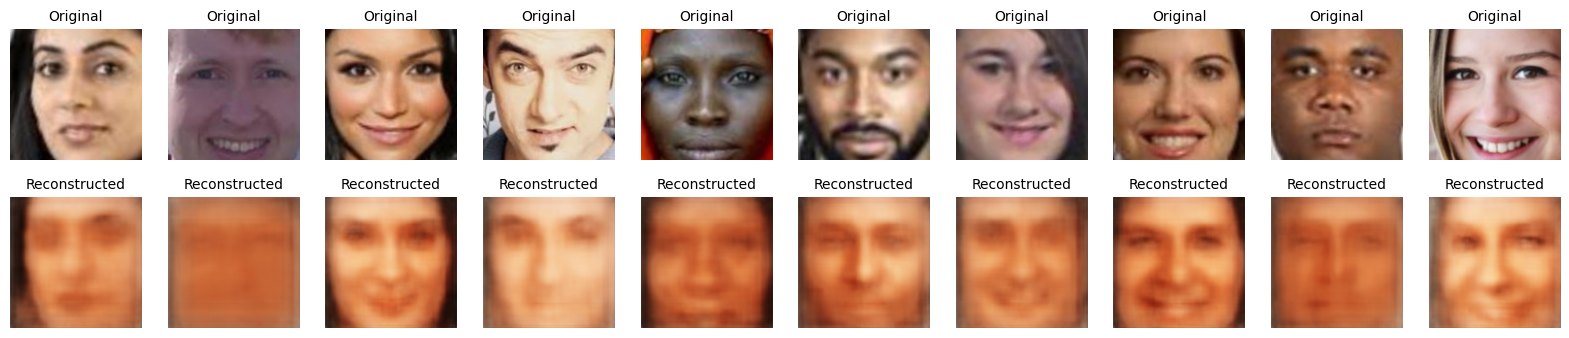

In [38]:
import matplotlib.pyplot as plt

n = 10

x_sample = tf.convert_to_tensor(x_test[:n], dtype=tf.float32)
# age_sample = tf.convert_to_tensor(x_test_ages[:n], dtype=tf.float32)
# age_sample = tf.convert_to_tensor([1,1,1,1,1,1,1,1,1,1], dtype=tf.float32)
age_sample = tf.convert_to_tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=tf.float32)

z_mean, z_log_var, z = vae.encoder([x_sample, age_sample], training=False)
decoded_imgs, _ = vae.decoder([z, age_sample], training=False)

plt.figure(figsize=(20, 4))
for i in range(n):
    # Imagen original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_sample[i].numpy())
    plt.axis("off")
    plt.title("Original", fontsize=10)

    # Imagen reconstruida
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].numpy())
    plt.axis("off")
    plt.title("Reconstructed", fontsize=10)

plt.show()


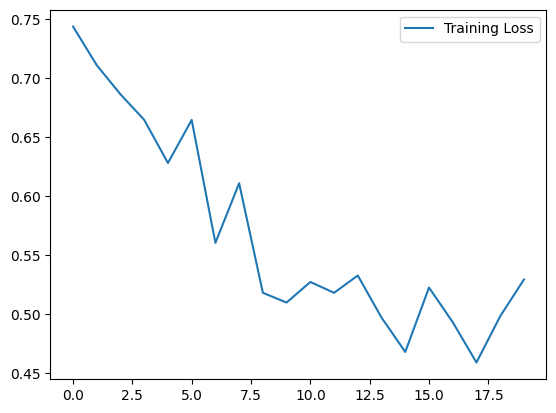

In [39]:
loss = history.history['loss']

epoch_range = range(epochs)

plt.plot(epoch_range, loss, label='Training Loss')
plt.legend()
plt.show()

In [40]:
def generate_age_variations(img_path, ages=[5, 15, 25, 40, 60, 80]):
    """
    Genera múltiples versiones de una imagen con diferentes edades.
    Requiere:
        - vae: modelo entrenado
        - preprocess_image: debe devolver recortes faciales normalizados [0,1]
    """

    # --- Preprocesamiento ---
    face_crops = preprocess_image(img_path)
    if len(face_crops) == 0:
        raise ValueError("No se detectó ninguna cara en la imagen.")

    face = face_crops[0]

    # Batch de tamaño 1
    face_batch = np.expand_dims(face, axis=0)
    face_tensor = tf.convert_to_tensor(face_batch, dtype=tf.float32)

    decoded_results = []

    # --- Procesar cada edad ---
    for age_value in ages:
        age_tensor = tf.convert_to_tensor([[age_value]], dtype=tf.float32)

        # Encode + obtener skips
        enc_out = vae.encoder([face_tensor, age_tensor], training=False)
        z_mean, z_log_var, z = enc_out[:3]

        # Decode con skips
        decoded_img, _ = vae.decoder([z, age_tensor], training=False)

        decoded_results.append(decoded_img[0].numpy())

    # --- Mostrar ---
    plt.figure(figsize=(3 * len(ages), 4))

    # Mostrar imagen original
    plt.subplot(1, len(ages) + 1, 1)
    plt.imshow(face)
    plt.title("Original")
    plt.axis("off")

    # Mostrar variaciones
    for i, age_value in enumerate(ages):
        plt.subplot(1, len(ages) + 1, i + 2)
        plt.imshow(decoded_results[i])
        plt.title(f"Edad: {age_value}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

    return decoded_results

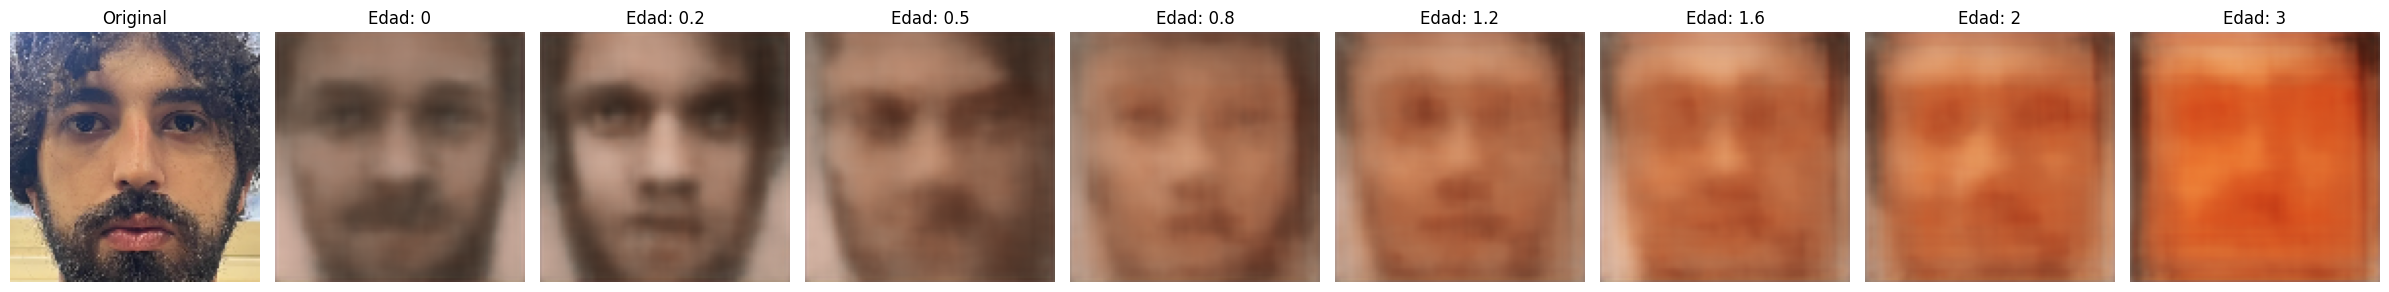

[array([[[0.39295086, 0.339233  , 0.30479425],
         [0.35451794, 0.28030765, 0.24908814],
         [0.35705107, 0.27862877, 0.25016078],
         ...,
         [0.34074563, 0.26026592, 0.2325162 ],
         [0.35827225, 0.2771718 , 0.24805309],
         [0.40993735, 0.33101317, 0.31102654]],
 
        [[0.35940793, 0.30668557, 0.26500228],
         [0.32519108, 0.2534107 , 0.21486942],
         [0.33296195, 0.25638843, 0.21636376],
         ...,
         [0.33933076, 0.25246933, 0.20884548],
         [0.3490562 , 0.25744602, 0.22209613],
         [0.38017043, 0.306557  , 0.27451968]],
 
        [[0.35537088, 0.30461442, 0.26550627],
         [0.32732642, 0.254738  , 0.22212148],
         [0.34236377, 0.26369873, 0.22924244],
         ...,
         [0.34350133, 0.26813775, 0.22948833],
         [0.33988947, 0.25904766, 0.23096994],
         [0.3656388 , 0.29773837, 0.26885164]],
 
        ...,
 
        [[0.7145557 , 0.61226445, 0.5731525 ],
         [0.76709086, 0.6415212 , 0.59917

In [41]:
generate_age_variations(
    img_path="../Images/A.jpg",
    # ages=[0, -5, -2 ,-1, 1, 2, 5]
    ages=[0, 0.2, 0.5, 0.8, 1.2, 1.6, 2, 3]
)